### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Load Dataset

In [2]:
import os, glob

path = r'E:\Machine-Learning-Projects\Python-ML-Lab\House-Price-Prediction\dataset'
if os.path.isdir(path):
    csvs = glob.glob(os.path.join(path, '*.csv'))
    if csvs:
        data = pd.read_csv(csvs[0])
    else:
        print("No CSV files found in the specified directory.")
else:
    print("The specified path is not a directory.")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Exploratory Data Analysis

### Display Last 5 Rows

In [3]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


### Check Shape

In [4]:
data.shape

(545, 13)

### Check Dataset Columns

In [5]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

### Check Dataset Information

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Check Duplicate Rows

In [8]:
data.duplicated().sum()

np.int64(0)

### Check Unique Values

In [9]:
for col in data.columns:
    print(col)
    print(data[col].unique())
    print("-"*40)

price
[13300000 12250000 12215000 11410000 10850000 10150000  9870000  9800000
  9681000  9310000  9240000  9100000  8960000  8890000  8855000  8750000
  8680000  8645000  8575000  8540000  8463000  8400000  8295000  8190000
  8120000  8080940  8043000  7980000  7962500  7910000  7875000  7840000
  7700000  7560000  7525000  7490000  7455000  7420000  7350000  7343000
  7245000  7210000  7140000  7070000  7035000  7000000  6930000  6895000
  6860000  6790000  6755000  6720000  6685000  6650000  6629000  6615000
  6580000  6510000  6475000  6440000  6419000  6405000  6300000  6293000
  6265000  6230000  6195000  6160000  6125000  6107500  6090000  6083000
  6020000  5950000  5943000  5880000  5873000  5866000  5810000  5803000
  5775000  5740000  5652500  5600000  5565000  5530000  5523000  5495000
  5460000  5425000  5390000  5383000  5320000  5285000  5250000  5243000
  5229000  5215000  5145000  5110000  5075000  5040000  5033000  5005000
  4970000  4956000  4935000  4907000  4900000

### Check Data Types

In [10]:
data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### Convert Yes / No Columns

In [11]:
yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in yes_no_columns:
    data[col] = data[col].map({"yes":1,"no":0})

### Encode Furnishing Status

In [12]:
data = pd.get_dummies(data,
                      columns=["furnishingstatus"],
                      drop_first=True)

### Check Outliers

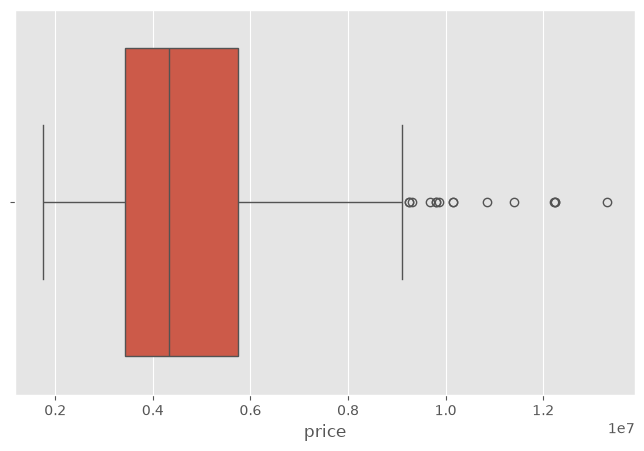

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["price"])

os.makedirs('plots', exist_ok=True)
plt.savefig('images/boxplot_price.png')

plt.show()

### Save Cleaned Dataset

In [14]:
data.to_csv("Housing_Cleaned.csv", index=False)

In [15]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


## Data Visualizations

In [16]:
plt.style.use("ggplot")

# Display all columns
pd.set_option('display.max_columns', None)

### Target Variable Distribution

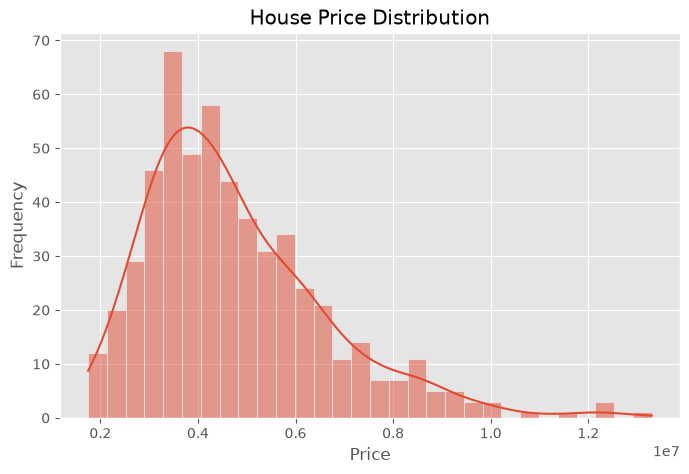

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(data["price"],
             kde=True,
             bins=30)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

os.makedirs("images", exist_ok=True)
plt.savefig("images/price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Distribution of Numeric Features

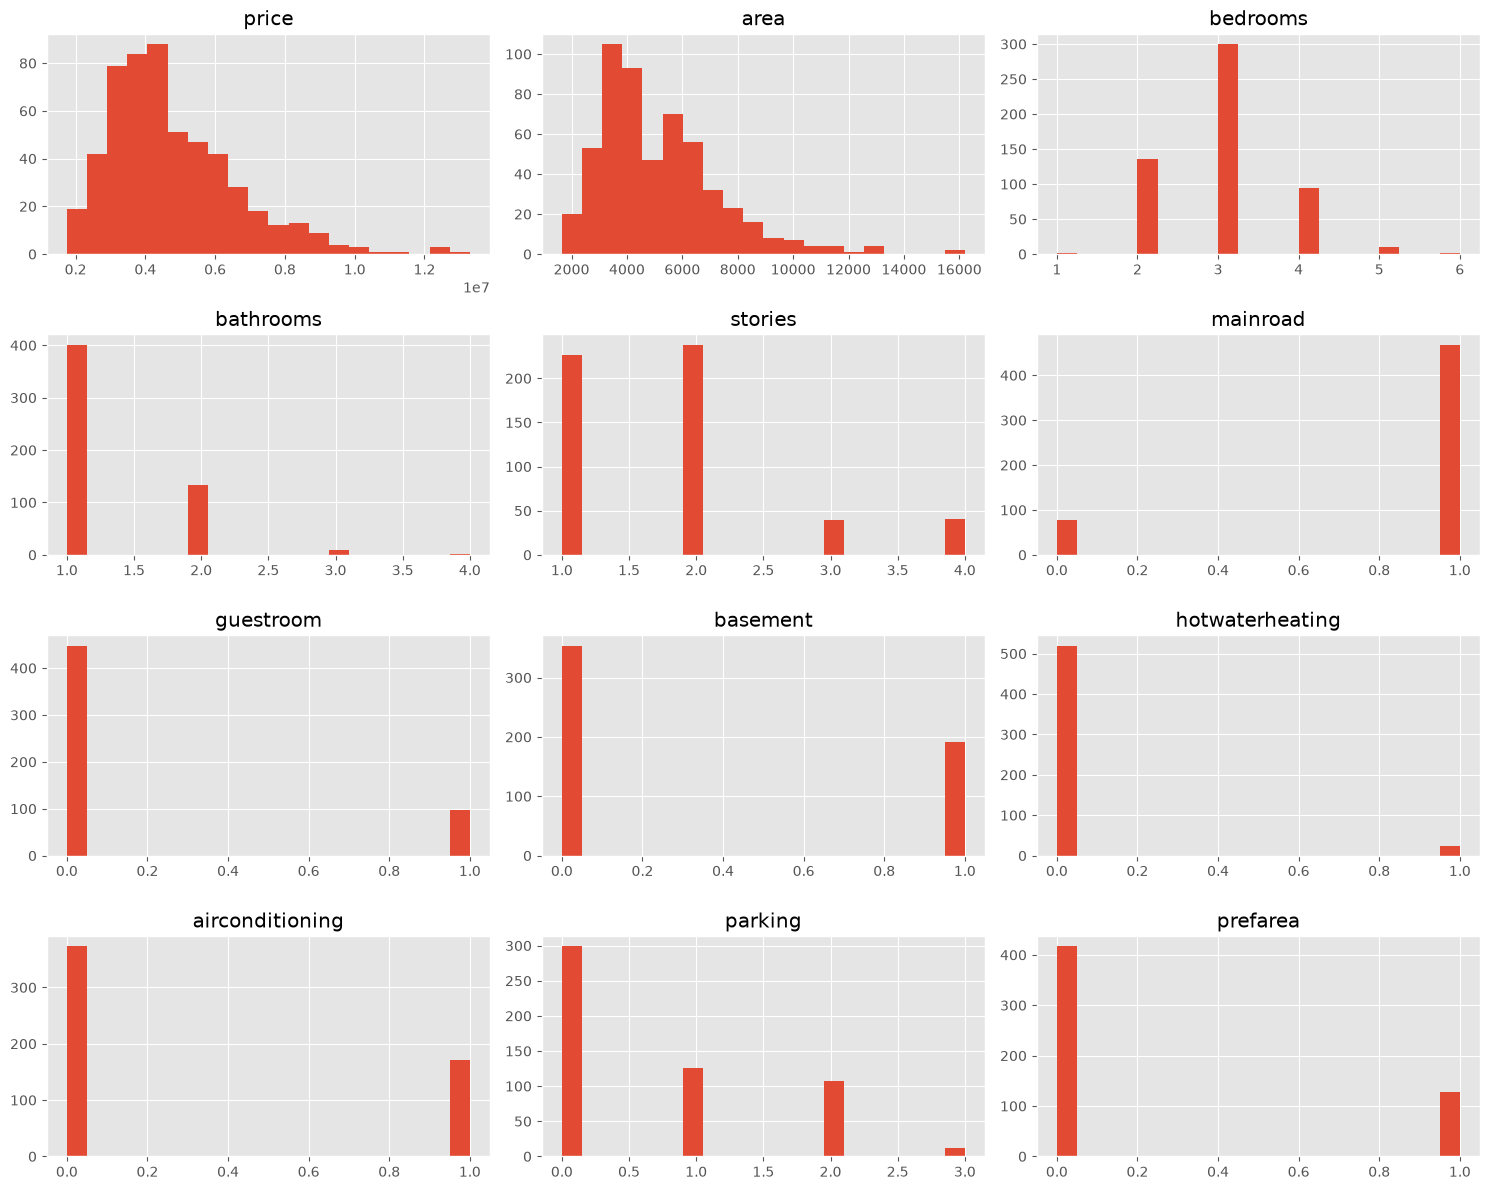

In [18]:
numeric_cols = data.select_dtypes(include=np.number).columns

data[numeric_cols].hist(figsize=(15,12),
                        bins=20)

plt.tight_layout()

plt.show()

### Correlation Heatmap

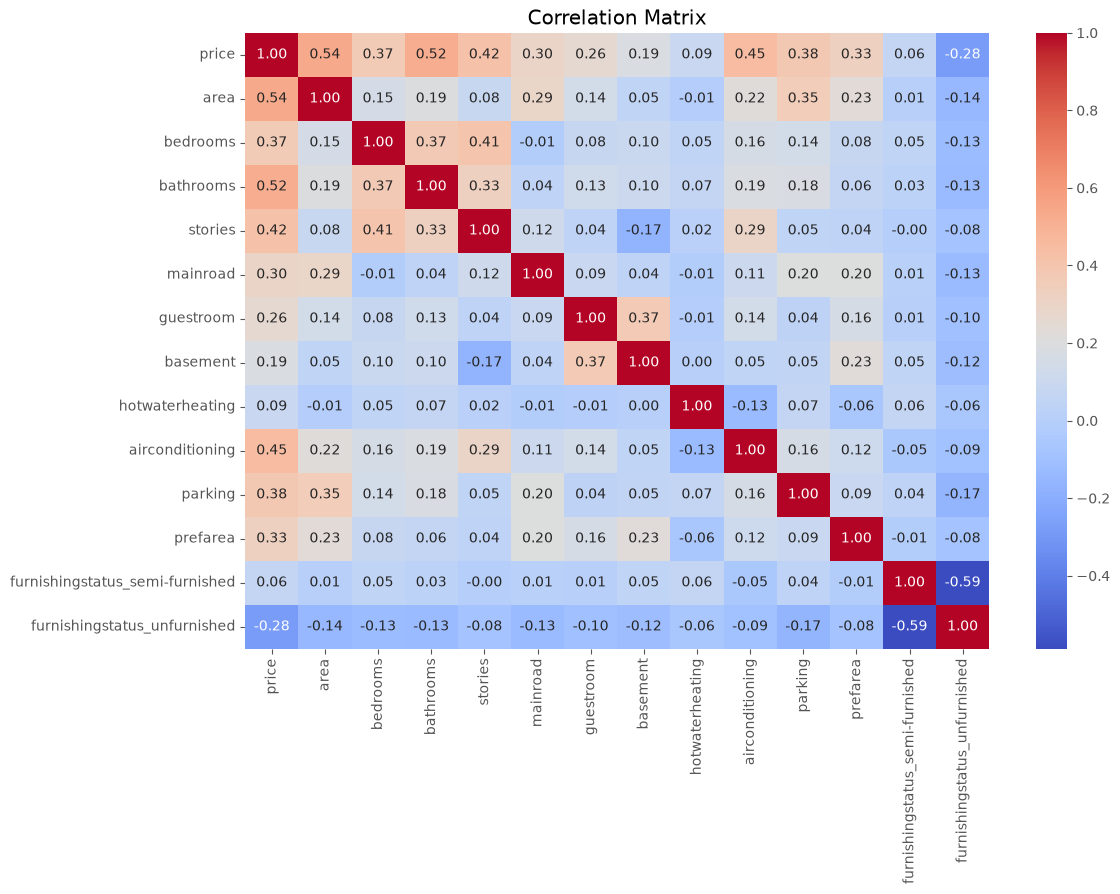

In [19]:
plt.figure(figsize=(12,8))

corr = data.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

os.makedirs("images", exist_ok=True)
plt.savefig("images/correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()

### Bedrooms vs Price

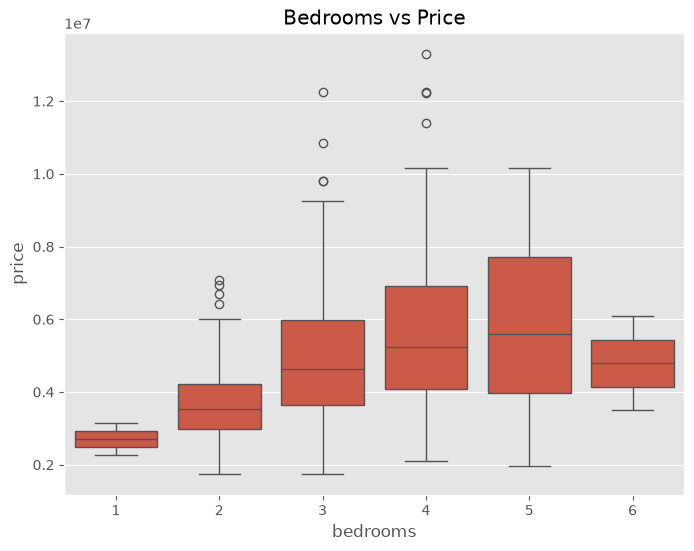

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(data=data,
            x="bedrooms",
            y="price")

plt.title("Bedrooms vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/bedrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Bathrooms vs Price

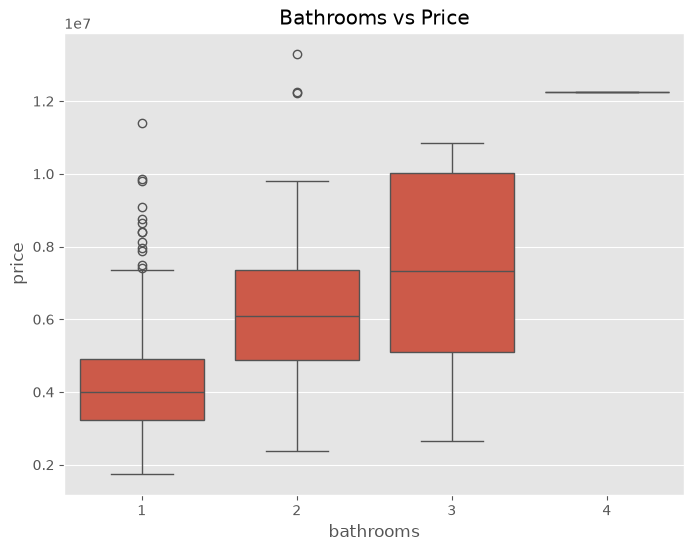

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(data=data,
            x="bathrooms",
            y="price")

plt.title("Bathrooms vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/bathrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Stories vs Price

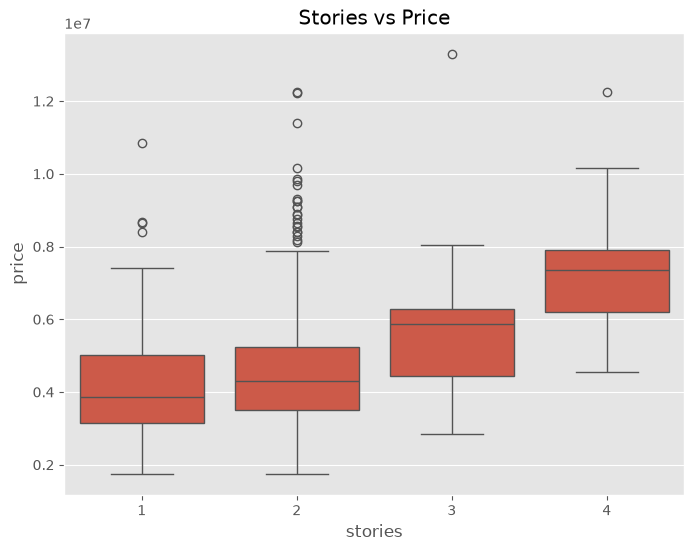

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(data=data,
            x="stories",
            y="price")

plt.title("Stories vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/stories_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Parking vs Price

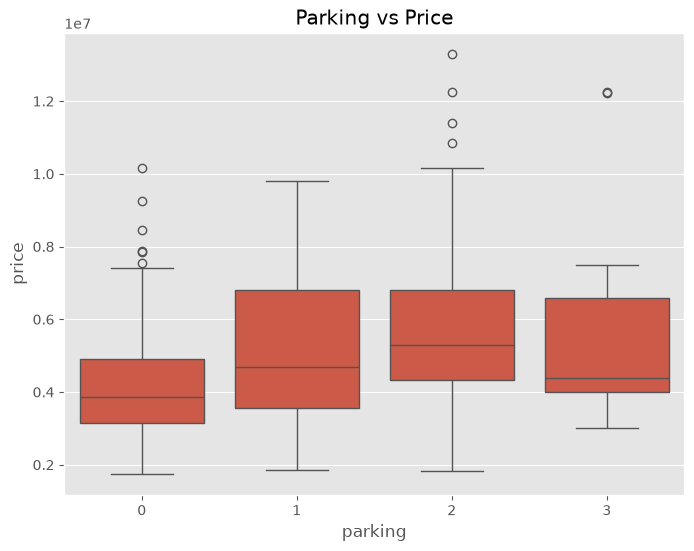

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(data=data,
            x="parking",
            y="price")

plt.title("Parking vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/parking_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Main Road vs Price

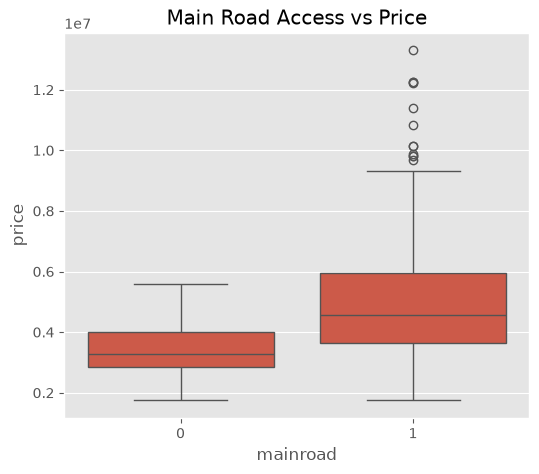

In [24]:
plt.figure(figsize=(6,5))

sns.boxplot(data=data,
            x="mainroad",
            y="price")

plt.title("Main Road Access vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/main_road_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Air Conditioning vs Price

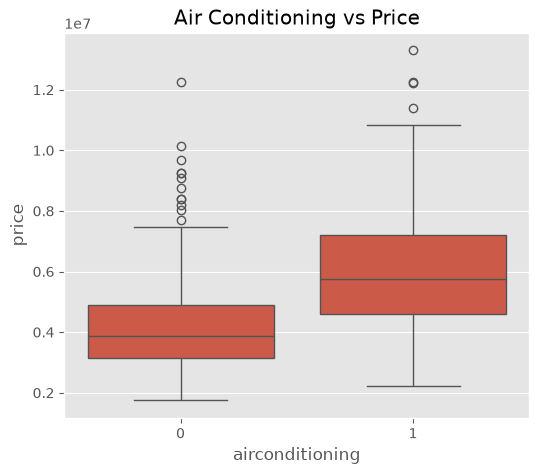

In [25]:
plt.figure(figsize=(6,5))

sns.boxplot(data=data,
            x="airconditioning",
            y="price")

plt.title("Air Conditioning vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/airconditioning_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Furnishing Status

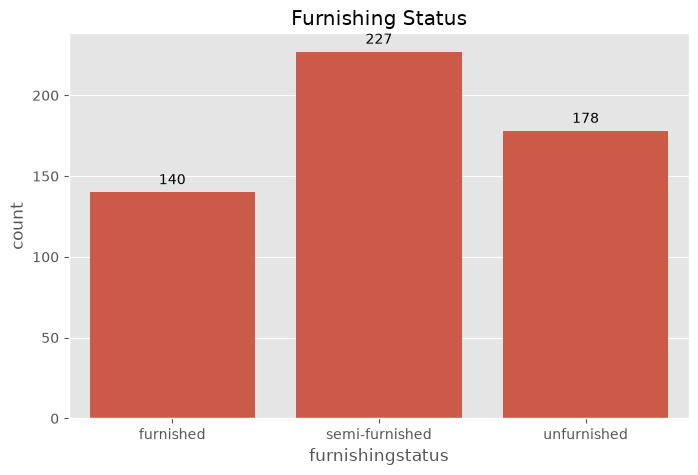

In [26]:
plt.figure(figsize=(8,5))

furnishing_counts = pd.DataFrame({
    "furnishingstatus": ["furnished", "semi-furnished", "unfurnished"],
    "count": [
        ((data["furnishingstatus_semi-furnished"] == False)
         & (data["furnishingstatus_unfurnished"] == False)).sum(),
        data["furnishingstatus_semi-furnished"].sum(),
        data["furnishingstatus_unfurnished"].sum()
    ]
})

sns.barplot(data=furnishing_counts,
            x="furnishingstatus",
            y="count")

for i, row in furnishing_counts.iterrows():
    plt.text(i, row["count"] + 5, str(row["count"]), ha='center')

plt.title("Furnishing Status")

os.makedirs("images", exist_ok=True)
plt.savefig("images/furnishing_status.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Price by Furnishing Status

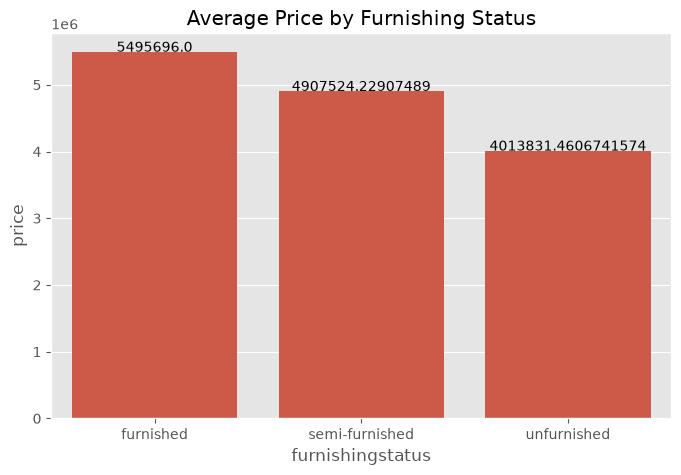

In [27]:
plt.figure(figsize=(8,5))

avg_price = pd.DataFrame({
    "furnishingstatus": ["furnished", "semi-furnished", "unfurnished"],
    "price": [
        data.loc[
            (~data["furnishingstatus_semi-furnished"])
            & (~data["furnishingstatus_unfurnished"]),
            "price"
        ].mean(),
        data.loc[data["furnishingstatus_semi-furnished"], "price"].mean(),
        data.loc[data["furnishingstatus_unfurnished"], "price"].mean()
    ]
})

sns.barplot(data=avg_price,
            x="furnishingstatus",
            y="price")

for i, row in avg_price.iterrows():
        plt.text(i, row["price"] + 5, str(row["price"]), ha='center')

plt.title("Average Price by Furnishing Status")

os.makedirs("images", exist_ok=True)
plt.savefig("images/avg_price_furnishing_status.png", dpi=300, bbox_inches="tight")
plt.show()

### Feature Relationships

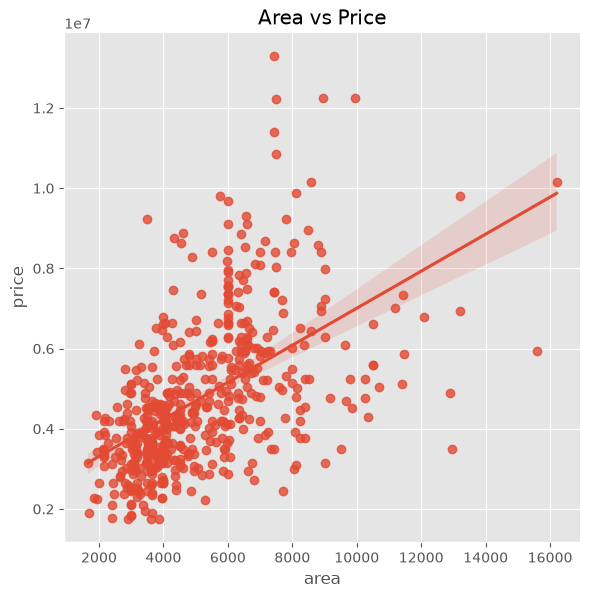

In [28]:
sns.lmplot(data=data,
           x="area",
           y="price",
           height=6)

plt.title("Area vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/area_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Violin Plot

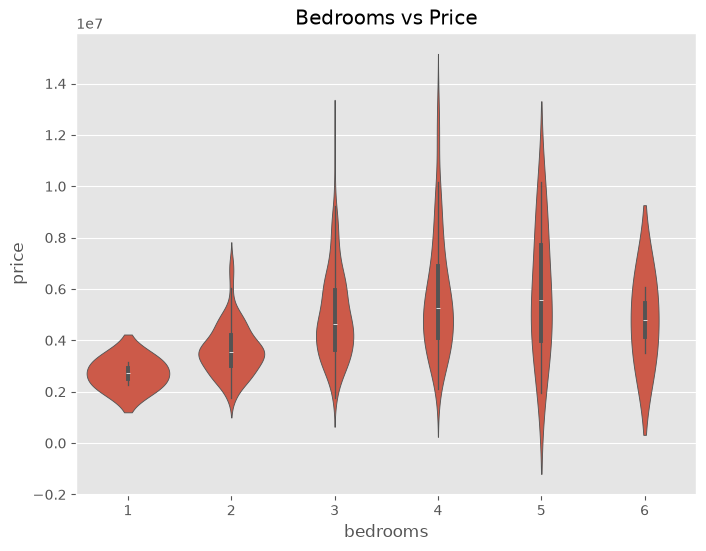

In [29]:
plt.figure(figsize=(8,6))

sns.violinplot(data=data,
               x="bedrooms",
               y="price")

plt.title("Bedrooms vs Price")

os.makedirs("images", exist_ok=True)
plt.savefig("images/bedrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Insights
- House area has a strong positive relationship with price.
- Houses with more bathrooms generally have higher prices.
- Furnished houses are more expensive than semi-furnished and unfurnished houses.
- Air conditioning and main road access are associated with higher house prices.
- Some numeric features contain outliers, particularly price and area.
- The target variable (price) is positively skewed.
- Correlation analysis shows area, bathrooms, and stories are among the most influential features.